In [1]:
import warnings
warnings.filterwarnings("ignore")
from sklearn.ensemble import RandomForestClassifier
import numpy as np
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
from sksurv.base import SurvivalAnalysisMixin as s
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sksurv.preprocessing import encode_categorical
from sksurv.functions import StepFunction
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis
from sksurv.ensemble import (ComponentwiseGradientBoostingSurvivalAnalysis, 
                            RandomSurvivalForest, 
                            ExtraSurvivalTrees, 
                            GradientBoostingSurvivalAnalysis, 
                            ExtraSurvivalTrees)
from sksurv.meta import EnsembleSelection, EnsembleSelectionRegressor
from sksurv.metrics import integrated_brier_score
from matplotlib.colors import ListedColormap
from mlxtend.evaluate import paired_ttest_5x2cv
from mlxtend.evaluate import combined_ftest_5x2cv
from lifelines import KaplanMeierFitter
from scipy.cluster import hierarchy
from lifelines.statistics import logrank_test, multivariate_logrank_test, pairwise_logrank_test
from sklearn import preprocessing
from sklearn.model_selection import StratifiedKFold, KFold
from lifelines.plotting import add_at_risk_counts
import scipy.stats
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna
from sklearn.model_selection import cross_val_score
from sksurv.metrics import integrated_brier_score
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor 
import statsmodels.api as sm
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.preprocessing import RobustScaler

In [2]:
# OUS: Train data
OUS_D1 = pd.read_csv('OUS_D1.csv')
OUS_D2 = pd.read_csv('OUS_D2.csv')
OUS_D3 = pd.read_csv('OUS_D3.csv')
OUS_DFS_target = pd.read_csv('OUS_DFS_target.csv')
OUS_OS_target = pd.read_csv('OUS_OS_target.csv')
response_OUS = pd.read_csv('response_ous.csv', sep=';')

# MAASTRO: Test data 
MAASTRO_D1 = pd.read_csv('MAASTRO_D1.csv')
MAASTRO_D2 = pd.read_csv('MAASTRO_D2.csv')
MAASTRO_D3 = pd.read_csv('MAASTRO_D3.csv')
MAASTRO_DFS_target = pd.read_csv('MAASTRO_DFS_target.csv')
MAASTRO_OS_target = pd.read_csv('MAASTRO_OS_target.csv')
response_MAASTRO = pd.read_csv('maastro_response_full.csv', sep=',')

In [3]:
# Need to choose patient_id from OUS_D1 in response_OUS
data = list(OUS_D1['patient_id'])
mask = response_OUS['patient_id'].isin(data)
response_OUS = response_OUS[mask] 

# Merge OUS_D1 with response_OUS
clinical_train = pd.merge(OUS_D1, response_OUS, on='patient_id', how='inner')
clinical_train = clinical_train.loc[:, ~clinical_train.columns.isin(['OS', 'event_OS', 'LRC', 'event_LRC'])]

In [4]:
# Drop patient_id column
clinical_train = clinical_train.drop('patient_id', axis=1)

In [5]:
# Check null values in D1
clinical_train.isnull().sum().sum()

0

## Test dataset: MAASTRO 

In [6]:
(MAASTRO_D1['patient_id'] == MAASTRO_OS_target['patient_id']).sum()

99

In [7]:
# Rename the column name of response_MAASTRO 
response_MAASTRO.rename(columns = {'Index' : 'patient_id'}, inplace = True)

In [8]:
# need to choose patient_id from MAASTRO_D1 in response_MAASTRO
data = list(MAASTRO_D1['patient_id'])
mask = response_MAASTRO['patient_id'].isin(data)
response_MAASTRO = response_MAASTRO[mask] 
response_MAASTRO

,patient_id,OS,OS_event,LRC,LRC_event,DFS,DFS_event
0,1,62.43,0.0,62.43,0.0,62.43,0.0
1,2,60.00,0.0,60.00,0.0,60.00,0.0
2,3,44.43,1.0,8.83,1.0,8.83,1.0
3,4,37.20,1.0,19.37,0.0,19.73,1.0
5,6,59.23,0.0,59.23,0.0,59.23,0.0
...,...,...,...,...,...,...,...
109,110,19.00,1.0,13.27,1.0,13.27,1.0
110,111,85.87,1.0,82.83,0.0,85.87,1.0
111,112,42.87,0.0,42.87,0.0,42.87,0.0
112,113,58.93,0.0,58.93,0.0,58.93,0.0


In [9]:
# Merge MAASTRO_D1 with response_MAASTRO
clinical_test = pd.merge(MAASTRO_D1, response_MAASTRO, on='patient_id', how='inner')
clinical_test = clinical_test.loc[:, ~clinical_test.columns.isin(['OS', 'OS_event', 'LRC', 'LRC_event'])]
clinical_test

,patient_id,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,DFS,DFS_event
0,1,55,0,0,1,0,0,1,1,1,0,0,15.438583,22.841,263.611623,62.43,0.0
1,2,55,0,0,1,0,0,0,0,0,20,1,8.829353,5.660,36.980700,60.00,0.0
2,3,55,0,0,1,0,0,0,0,1,6,1,13.476123,7.791,74.636342,8.83,1.0
3,4,61,1,0,0,0,1,1,0,1,45,1,8.632732,7.908,46.791979,19.73,1.0
4,6,70,0,0,1,0,0,1,1,1,59,0,9.783954,15.237,107.637514,59.23,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,110,66,1,0,0,0,1,0,0,0,55,1,31.338410,6.110,144.490782,13.27,1.0
95,111,63,0,0,0,0,1,0,0,1,174,1,13.041604,7.182,69.214868,85.87,1.0
96,112,63,0,0,1,0,0,1,1,1,0,1,8.944517,16.483,102.594274,42.87,0.0
97,113,54,0,0,1,0,0,1,1,0,0,0,14.184236,9.981,103.229492,58.93,0.0


In [10]:
# Drop patient_id column
clinical_test = clinical_test.drop('patient_id', axis=1)

In [11]:
# Some rows have null values in OS, OS_event -> Remove those rows
clinical_test[clinical_test.isnull().any(axis=1)]
clinical_test = clinical_test.dropna(how='any',axis=0) 

,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,DFS,DFS_event


In [12]:
# X
X = clinical_train.loc[:, ~clinical_train.columns.isin(['DFS', 'event_DFS'])]

# y 
y = clinical_train.loc[:, ['DFS', 'event_DFS']]

In [13]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [14]:
# Shape
print('X_train: ', X.shape)
print('y_train: ', y.shape)

X_train:  (139, 14)
y_train:  (139,)


In [15]:
clinical_test.rename(columns = {'DFS_event' : 'event_DFS'}, inplace = True)

In [16]:
# X
X_MAASTRO = clinical_test.loc[:, ~clinical_test.columns.isin(['DFS', 'event_DFS'])]

# y y_MAASTRO
y_MAASTRO = clinical_test.loc[:, ['DFS', 'event_DFS']]
lower, upper = np.percentile(y_MAASTRO['DFS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y_MAASTRO['event_DFS'], y_MAASTRO['DFS']): 
    lists.append((i, j))

y_MAASTRO = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

clinical_test.shape

(99, 16)

# Feature Selection with Random Forest

In [17]:
# Setting y 
y_rsf_classifier = clinical_train['event_DFS']

# Define parameters for StratifiedKFold
n_splits = 5
n_repeats = 4

# Initialize variables to store results
all_feature_importances = []

# Perform stratified 5-split 4 times and train Random Forest Classifier for each split
for i in range(n_repeats):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=i)  # Use different random_state for each repeat
    repeat_feature_importances = []
    
    for train_index, test_index in skf.split(X, y_rsf_classifier):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y_rsf_classifier.iloc[train_index], y_rsf_classifier.iloc[test_index]

        # Train Random Forest Classifier
        rf_classifier = RandomForestClassifier(random_state=i)  # You can adjust parameters as needed
        rf_classifier.fit(X_train, y_train)

        # Store feature importances
        repeat_feature_importances.append(rf_classifier.feature_importances_)

    all_feature_importances.append(repeat_feature_importances)

# Convert to numpy array for easier manipulation
all_feature_importances = np.array(all_feature_importances)

# Sum feature importances across repeats and folds
sum_feature_importances = np.sum(all_feature_importances, axis=(0, 1))

# Get feature names
feature_names = list(X)

# Create a DataFrame
df_feature_importances = pd.DataFrame({'Feature': feature_names, 'Importance_Sum': sum_feature_importances})

# Sort feature importances by their sum
df_feature_importances_sorted = df_feature_importances.sort_values(by='Importance_Sum', ascending=False)

RandomForestClassifier(random_state=0)

RandomForestClassifier(random_state=0)

RandomForestClassifier(random_state=0)

RandomForestClassifier(random_state=0)

RandomForestClassifier(random_state=0)

...

RandomForestClassifier(random_state=3)

RandomForestClassifier(random_state=3)

RandomForestClassifier(random_state=3)

RandomForestClassifier(random_state=3)

RandomForestClassifier(random_state=3)

<Figure size 1000x600 with 0 Axes>

<BarContainer object of 14 artists>

Text(0.5, 0, 'Features')

Text(0, 0.5, 'Sum of Absolute Importance Values')

Text(0.5, 1.0, 'Feature Importance using Random Forest Classifier')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

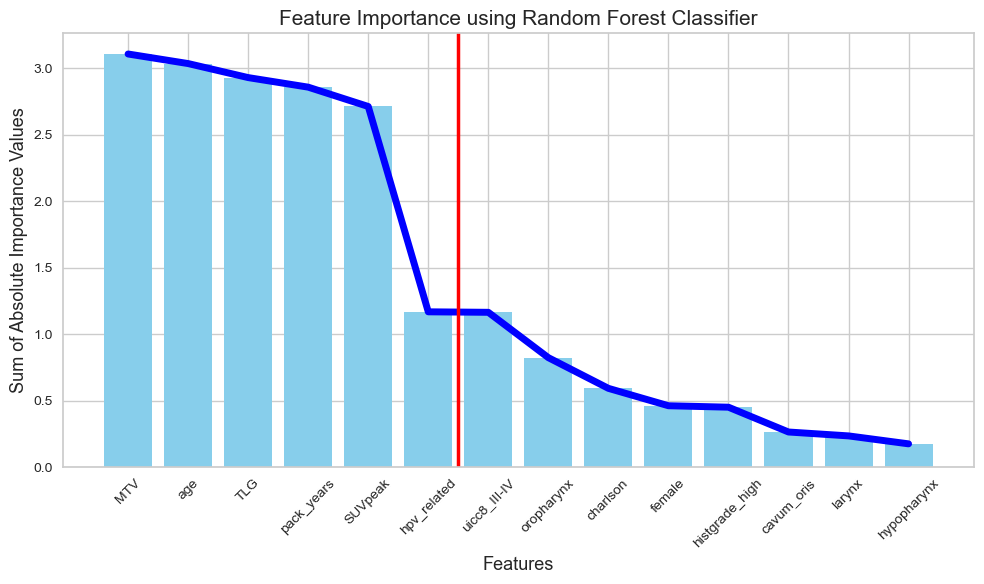

In [22]:
# Plot the bar graph
plt.figure(figsize=(10, 6)) 
plt.bar(df_feature_importances_sorted['Feature'], 
        df_feature_importances_sorted['Importance_Sum'], 
        color='skyblue')
plt.plot(df_feature_importances_sorted['Feature'], 
         df_feature_importances_sorted['Importance_Sum'], 
         color='blue',
        linewidth=5)
plt.xlabel('Features', fontsize=13) 
plt.ylabel('Sum of Absolute Importance Values', fontsize=13) 
plt.title('Feature Importance using Random Forest Classifier', fontsize=15)
plt.xticks(rotation=45) 
plt.axvline(x=5.5, color='red', linestyle='-', linewidth=2.5) 
plt.tight_layout()  
plt.show()

In [23]:
selected_features = df_feature_importances_sorted[0:6]['Feature']

In [24]:
selected_features

12            MTV
0             age
13            TLG
9      pack_years
11        SUVpeak
7     hpv_related
Name: Feature, dtype: object

In [25]:
X_rf = X[selected_features]
X_new = X_rf.copy() 

X_MAASTRO_rf = X_MAASTRO[selected_features]
MAASTRO_new = X_MAASTRO_rf.copy()

# Standardization

In [26]:
original_X = X.copy()

In [27]:
# Standardize X_new, the new data with the selected features only 
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']

# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in X_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
X_new_categoric = X_new[columns_to_drop]
X_new_numeric = X_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
scaler = RobustScaler() 
X_new_numeric_columns = X_new_numeric.columns
X_new_numeric_index = X_new_numeric.index 
X_new_numeric_std = scaler.fit_transform(X_new_numeric)
X_new_numeric_std = pd.DataFrame(X_new_numeric_std,
                                 columns=X_new_numeric_columns, 
                                 index=X_new_numeric_index)
X_new_std = pd.concat([X_new_numeric_std, X_new_categoric], axis=1)

# Change the order of the X_new_std 
X_new_std = X_new_std[X_new.columns]

In [33]:
# Standardize X_MAASTRO 
# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in MAASTRO_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
MAASTRO_new_categoric = MAASTRO_new[columns_to_drop]
MAASTRO_new_numeric = MAASTRO_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns
MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns
MAASTRO_new_numeric_index = MAASTRO_new_numeric.index 
MAASTRO_new_numeric_std = scaler.transform(MAASTRO_new_numeric)
MAASTRO_new_numeric_std = pd.DataFrame(MAASTRO_new_numeric_std,
                                 columns=MAASTRO_new_numeric_columns, 
                                 index=MAASTRO_new_numeric_index)
MAASTRO_new_std = pd.concat([MAASTRO_new_numeric_std, MAASTRO_new_categoric], axis=1)

# Change the order of the X_new_std 
MAASTRO_new = MAASTRO_new[X_new.columns]
MAASTRO_new_std = MAASTRO_new_std[X_new.columns]

In [34]:
X_new

,MTV,age,TLG,pack_years,SUVpeak,hpv_related
0,7.934,54.238356,86.228420,0.000000,14.473272,0.0
1,1.656,54.539726,7.040100,27.404795,5.044678,0.0
2,14.502,59.019178,83.569669,41.019178,7.839043,0.0
3,2.440,70.726027,5.567091,37.500000,2.880631,0.0
4,3.668,67.865753,16.150550,53.000000,5.402006,0.0
...,...,...,...,...,...,...
134,3.650,60.435616,26.280140,0.000000,9.290139,1.0
135,18.967,68.794521,101.754834,0.000000,7.172883,1.0
136,6.370,57.498630,66.273201,39.498630,13.873187,1.0
137,12.443,65.684932,71.832443,71.527397,7.507419,1.0


In [35]:
X_new_std

,MTV,age,TLG,pack_years,SUVpeak,hpv_related
0,0.075008,-0.497635,0.231096,-0.747766,0.600320,0.0
1,-0.466877,-0.473435,-0.387041,0.159774,-0.690705,0.0
2,0.641923,-0.113739,0.210342,0.610629,-0.308082,0.0
3,-0.399206,0.826312,-0.398539,0.494088,-0.987020,0.0
4,-0.293211,0.596634,-0.315926,1.007387,-0.641777,0.0
...,...,...,...,...,...,...
134,-0.294765,0.000000,-0.236855,-0.747766,-0.109388,1.0
135,1.027319,0.671213,0.352293,-0.747766,-0.399297,1.0
136,-0.059989,-0.235838,0.075327,0.560275,0.518153,1.0
137,0.464201,0.421516,0.118722,1.620942,-0.353490,1.0


In [36]:
MAASTRO_new

,MTV,age,TLG,pack_years,SUVpeak,hpv_related
0,22.841,55,263.611623,0,15.438583,1
1,5.660,55,36.980700,20,8.829353,0
2,7.791,55,74.636342,6,13.476123,0
3,7.908,61,46.791979,45,8.632732,0
4,15.237,70,107.637514,59,9.783954,1
...,...,...,...,...,...,...
94,6.110,66,144.490782,55,31.338410,0
95,7.182,63,69.214868,174,13.041604,0
96,16.483,63,102.594274,0,8.944517,1
97,9.981,54,103.229492,0,14.184236,1


In [37]:
MAASTRO_new_std

,MTV,age,TLG,pack_years,SUVpeak,hpv_related
0,1.361702,-0.436476,1.615732,-0.747766,0.732497,1
1,-0.121272,-0.436476,-0.153327,-0.085444,-0.172482,0
2,0.062665,-0.436476,0.140609,-0.549070,0.463784,0
3,0.072763,0.045320,-0.076742,0.742458,-0.199405,0
4,0.705364,0.768012,0.398213,1.206084,-0.041772,1
...,...,...,...,...,...,...
94,-0.082431,0.446816,0.685886,1.073619,2.909606,0
95,0.010099,0.205918,0.098289,5.014436,0.404287,0
96,0.812913,0.205918,0.358846,-0.747766,-0.156713,1
97,0.251694,-0.516775,0.363804,-0.747766,0.560744,1


# Modelling 

### 1. CoxPHSurvivalAnalysis

#### Train

In [38]:
# Setting the y format for skf below  
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class()
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxPHSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxPHSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-13 17:08:44,473] A new study created in memory with name: no-name-dc55b428-00e1-4d98-9222-3b561a22670f


  0%|          | 0/1 [00:00<?, ?it/s]

[I 2024-04-13 17:08:48,388] A new study created in memory with name: no-name-04a4158c-b889-417b-be80-e5505913a867


Fold 1 C-index: 0.6055776892430279
Fold 2 C-index: 0.6124031007751938
Fold 3 C-index: 0.7489361702127659
Fold 4 C-index: 0.6425855513307985
Fold 5 C-index: 0.6008583690987125
[I 2024-04-13 17:08:48,378] Trial 0 finished with value: 0.6420721761320998 and parameters: {}. Best is trial 0 with value: 0.6420721761320998.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.6420721761320998], datetime_start=datetime.datetime(2024, 4, 13, 17, 8, 44, 558333), datetime_complete=datetime.datetime(2024, 4, 13, 17, 8, 48, 377594), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.6420721761320998


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.23739654975422636
Fold 2 IBS: 0.23711627545196068
Fold 3 IBS: 0.18420507803344355
Fold 4 IBS: 0.2783516363533258
Fold 5 IBS: 0.2160380291037775
[I 2024-04-13 17:08:48,665] Trial 0 finished with value: 0.2306215137393468 and parameters: {}. Best is trial 0 with value: 0.2306215137393468.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.2306215137393468], datetime_start=datetime.datetime(2024, 4, 13, 17, 8, 48, 430534), datetime_complete=datetime.datetime(2024, 4, 13, 17, 8, 48, 664953), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.2306215137393468


In [39]:
# Setting a dictionary to save the train results 
train_cindex = {} 
train_ibs = {} 

# Saving the values to the dictionary 
train_cindex['CoxPH'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxPH'] = np.round(study_ibs.best_value, 3)

In [40]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.642
train_ibs:  0.231


#### Test

In [41]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [42]:
# Test on MAASTRO 
cph = CoxPHSurvivalAnalysis()

cph.fit(X_new_std, y)

# Save C-index 
c_index = cph.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print('Concordance index:', c_index)

# Save IBS 
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in cph.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print('IBS score:', ibs)

CoxPHSurvivalAnalysis()

Concordance index: 0.613
IBS score: 0.258


In [43]:
# Setting a dictionary to save the test results 
test_cindex = {} 
test_ibs = {} 

In [44]:
# Saving the values to the dictionary 
test_cindex['CoxPH'] = c_index
test_ibs['CoxPH'] = ibs

### 2. CoxnetSurvivalAnalysis - Ridge

#### Train

In [45]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=0.0000001, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 17:08:48,899] A new study created in memory with name: no-name-e064aec8-ce20-45bb-8f44-36b34ee8d99f


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.5936254980079682
Fold 2 C-index: 0.5251937984496124


[I 2024-04-13 17:08:49,063] A new study created in memory with name: no-name-bad4848f-4504-4cc4-942f-1b1cc1506886


Fold 3 C-index: 0.6127659574468085
Fold 4 C-index: 0.4695817490494297
Fold 5 C-index: 0.6051502145922747
[I 2024-04-13 17:08:49,055] Trial 0 finished with value: 0.5612634435092188 and parameters: {}. Best is trial 0 with value: 0.5612634435092188.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.5612634435092188], datetime_start=datetime.datetime(2024, 4, 13, 17, 8, 48, 937249), datetime_complete=datetime.datetime(2024, 4, 13, 17, 8, 49, 55001), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.5612634435092188


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.24724709437692782
Fold 2 IBS: 0.23203988483138108
Fold 3 IBS: 0.228981863802055
Fold 4 IBS: 0.24197478945971077
Fold 5 IBS: 0.2293955883720722
[I 2024-04-13 17:08:49,253] Trial 0 finished with value: 0.23592784416842932 and parameters: {}. Best is trial 0 with value: 0.23592784416842932.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.23592784416842932], datetime_start=datetime.datetime(2024, 4, 13, 17, 8, 49, 100224), datetime_complete=datetime.datetime(2024, 4, 13, 17, 8, 49, 253434), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.23592784416842932


In [46]:
train_cindex['CoxRidge'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxRidge'] = np.round(study_ibs.best_value, 3)

In [47]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.561
train_ibs:  0.236


#### Test

In [48]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [49]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 0.0000001
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_cindex : 0.554


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_ibs:  0.229


In [50]:
# Saving the values to the dictionary 
test_cindex['CoxRidge'] = c_index
test_ibs['CoxRidge'] = ibs

### 3. CoxnetSurvivalAnalysis - Lasso

#### Train

In [51]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=1, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 17:08:49,441] A new study created in memory with name: no-name-63f88b28-be06-4ff3-83a5-dd472b995d0e


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.601593625498008
Fold 2 C-index: 0.6124031007751938
Fold 3 C-index: 0.7489361702127659
Fold 4 C-index: 0.6425855513307985
Fold 5 C-index: 0.5965665236051502
[I 2024-04-13 17:08:49,754] Trial 0 finished with value: 0.6404169942843833 and parameters: {}. Best is trial 0 with value: 0.6404169942843833.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.6404169942843833], datetime_start=datetime.datetime(2024, 4, 13, 17, 8, 49, 482590), datetime_complete=datetime.datetime(2024, 4, 13, 17, 8, 49, 754827), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.6404169942843833


[I 2024-04-13 17:08:49,762] A new study created in memory with name: no-name-8ca62915-3da5-4b4a-a726-d2f5171213fd


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.2363981433519798
Fold 2 IBS: 0.23626589517684174
Fold 3 IBS: 0.18518589604161975
Fold 4 IBS: 0.27757925655859705
Fold 5 IBS: 0.21560999470143538
[I 2024-04-13 17:08:50,043] Trial 0 finished with value: 0.23020783716609472 and parameters: {}. Best is trial 0 with value: 0.23020783716609472.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.23020783716609472], datetime_start=datetime.datetime(2024, 4, 13, 17, 8, 49, 787933), datetime_complete=datetime.datetime(2024, 4, 13, 17, 8, 50, 40622), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.23020783716609472


In [52]:
train_cindex['CoxLasso'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxLasso'] = np.round(study_ibs.best_value, 3)

In [53]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.64
train_ibs:  0.23


#### Test

In [54]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [55]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 1
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_cindex : 0.612


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_ibs:  0.258


In [56]:
# Saving the values to the dictionary 
test_cindex['CoxLasso'] = c_index
test_ibs['CoxLasso'] = ibs

### 4. CoxnetSurvivalAnalysis - ElasticNet

#### Train

In [57]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        l1_ratio = trial.suggest_float("l1_ratio", 0.0001, 1)
        
        # Create and fit survival model 
        model = model_class(l1_ratio=l1_ratio, 
                           fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 17:08:50,268] A new study created in memory with name: no-name-4d4917d1-ab8d-4d22-b567-7efe82f7e117


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.601593625498008
Fold 2 C-index: 0.6124031007751938
Fold 3 C-index: 0.7446808510638298
Fold 4 C-index: 0.6425855513307985
Fold 5 C-index: 0.5965665236051502
[I 2024-04-13 17:08:50,564] Trial 0 finished with value: 0.6395659304545961 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.6395659304545961.
Fold 1 C-index: 0.6055776892430279
Fold 2 C-index: 0.6124031007751938
Fold 3 C-index: 0.7446808510638298
Fold 4 C-index: 0.6425855513307985
Fold 5 C-index: 0.5965665236051502
[I 2024-04-13 17:08:50,848] Trial 1 finished with value: 0.6403627432036001 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 1 with value: 0.6403627432036001.
Fold 1 C-index: 0.6055776892430279
Fold 2 C-index: 0.6124031007751938
Fold 3 C-index: 0.7446808510638298
Fold 4 C-index: 0.6387832699619772
Fold 5 C-index: 0.592274678111588
[I 2024-04-13 17:08:51,075] Trial 2 finished with value: 0.6387439178311234 and parameters: {'l1_ratio': 0.22692876841884668}. B

Fold 3 C-index: 0.7489361702127659
Fold 4 C-index: 0.6425855513307985
Fold 5 C-index: 0.5965665236051502
[I 2024-04-13 17:08:56,293] Trial 24 finished with value: 0.6404169942843833 and parameters: {'l1_ratio': 0.9034493106664918}. Best is trial 12 with value: 0.6412138070333873.
Fold 1 C-index: 0.6055776892430279
Fold 2 C-index: 0.6124031007751938
Fold 3 C-index: 0.7446808510638298
Fold 4 C-index: 0.6425855513307985
Fold 5 C-index: 0.5965665236051502
[I 2024-04-13 17:08:56,549] Trial 25 finished with value: 0.6403627432036001 and parameters: {'l1_ratio': 0.6388867827470202}. Best is trial 12 with value: 0.6412138070333873.
Fold 1 C-index: 0.601593625498008
Fold 2 C-index: 0.6124031007751938
Fold 3 C-index: 0.7489361702127659
Fold 4 C-index: 0.6425855513307985
Fold 5 C-index: 0.5965665236051502
[I 2024-04-13 17:08:56,925] Trial 26 finished with value: 0.6404169942843833 and parameters: {'l1_ratio': 0.9167426588025347}. Best is trial 12 with value: 0.6412138070333873.
Fold 1 C-index: 0.

Fold 2 C-index: 0.6124031007751938
Fold 3 C-index: 0.7446808510638298
Fold 4 C-index: 0.6425855513307985
Fold 5 C-index: 0.5965665236051502
[I 2024-04-13 17:09:02,282] Trial 48 finished with value: 0.6403627432036001 and parameters: {'l1_ratio': 0.6477084808266885}. Best is trial 12 with value: 0.6412138070333873.
Fold 1 C-index: 0.6055776892430279
Fold 2 C-index: 0.6124031007751938
Fold 3 C-index: 0.7446808510638298
Fold 4 C-index: 0.6425855513307985
Fold 5 C-index: 0.5965665236051502
[I 2024-04-13 17:09:02,520] Trial 49 finished with value: 0.6403627432036001 and parameters: {'l1_ratio': 0.4477016529538363}. Best is trial 12 with value: 0.6412138070333873.
Fold 1 C-index: 0.6055776892430279
Fold 2 C-index: 0.6124031007751938
Fold 3 C-index: 0.7489361702127659
Fold 4 C-index: 0.6425855513307985
Fold 5 C-index: 0.5965665236051502
[I 2024-04-13 17:09:02,746] Trial 50 finished with value: 0.6412138070333873 and parameters: {'l1_ratio': 0.820181889729209}. Best is trial 12 with value: 0.6

...

  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 IBS: 0.23642382583276575
Fold 2 IBS: 0.23617423415511002
Fold 3 IBS: 0.18520370571653597
Fold 4 IBS: 0.2775970154806221
Fold 5 IBS: 0.2153307986781532
[I 2024-04-13 17:09:14,066] Trial 0 finished with value: 0.2301459159726374 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.2301459159726374.
Fold 1 IBS: 0.23665104559536604
Fold 2 IBS: 0.2361208812624102
Fold 3 IBS: 0.18515747307084002
Fold 4 IBS: 0.27751824875530245
Fold 5 IBS: 0.21489944420549947
[I 2024-04-13 17:09:14,324] Trial 1 finished with value: 0.23006941857788363 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 1 with value: 0.23006941857788363.
Fold 1 IBS: 0.2367070773733159
Fold 2 IBS: 0.2361219141053181
Fold 3 IBS: 0.1851138004858678
Fold 4 IBS: 0.277485150084561
Fold 5 IBS: 0.21490459332467596
[I 2024-04-13 17:09:14,569] Trial 2 finished with value: 0.23006650707474777 and parameters: {'l1_ratio': 0.22692876841884668}. Best is trial 2 with value: 0.23006650707474777.


Fold 1 IBS: 0.23658954305481242
Fold 2 IBS: 0.23613692998669006
Fold 3 IBS: 0.18519570021262904
Fold 4 IBS: 0.2775193361960889
Fold 5 IBS: 0.21503509631626833
[I 2024-04-13 17:09:21,012] Trial 25 finished with value: 0.23009532115329775 and parameters: {'l1_ratio': 0.3747482470228898}. Best is trial 22 with value: 0.22940284382674986.
Fold 1 IBS: 0.24635740164793704
Fold 2 IBS: 0.23209045006538398
Fold 3 IBS: 0.2283483454351303
Fold 4 IBS: 0.24478642080018442
Fold 5 IBS: 0.22869838496256165
[I 2024-04-13 17:09:21,169] Trial 26 finished with value: 0.23605620058223947 and parameters: {'l1_ratio': 0.015423757551295547}. Best is trial 22 with value: 0.22940284382674986.
Fold 1 IBS: 0.23671333042655748
Fold 2 IBS: 0.23614140000666126
Fold 3 IBS: 0.18518538560993006
Fold 4 IBS: 0.2775070657692229
Fold 5 IBS: 0.21483511660130858
[I 2024-04-13 17:09:21,440] Trial 27 finished with value: 0.23007645968273605 and parameters: {'l1_ratio': 0.2329675843966648}. Best is trial 22 with value: 0.229402

Fold 1 IBS: 0.23654927576649962
Fold 2 IBS: 0.23620556006663948
Fold 3 IBS: 0.18514924295999224
Fold 4 IBS: 0.2775281127993251
Fold 5 IBS: 0.2150702725566834
[I 2024-04-13 17:09:27,994] Trial 50 finished with value: 0.23010049282982797 and parameters: {'l1_ratio': 0.41653985858071785}. Best is trial 42 with value: 0.22940244387746933.
Fold 1 IBS: 0.23676644825921508
Fold 2 IBS: 0.23615886134178127
Fold 3 IBS: 0.18513251295995037
Fold 4 IBS: 0.27749236230957314
Fold 5 IBS: 0.2147900822015218
[I 2024-04-13 17:09:28,316] Trial 51 finished with value: 0.23006805341440834 and parameters: {'l1_ratio': 0.19031596268046638}. Best is trial 42 with value: 0.22940244387746933.
Fold 1 IBS: 0.23678334576867607
Fold 2 IBS: 0.23292931689915944
Fold 3 IBS: 0.1851292177383303
Fold 4 IBS: 0.2774701731652638
Fold 5 IBS: 0.21474639832009568
[I 2024-04-13 17:09:28,609] Trial 52 finished with value: 0.22941169037830506 and parameters: {'l1_ratio': 0.16901987791340187}. Best is trial 42 with value: 0.2294024

Fold 1 IBS: 0.23679098775310575
Fold 2 IBS: 0.23278901806069965
Fold 3 IBS: 0.22446693492624417
Fold 4 IBS: 0.2774317528568419
Fold 5 IBS: 0.21478945580846537
[I 2024-04-13 17:09:34,654] Trial 75 finished with value: 0.23725362988107138 and parameters: {'l1_ratio': 0.1471515362767744}. Best is trial 42 with value: 0.22940244387746933.
Fold 1 IBS: 0.23672366505042472
Fold 2 IBS: 0.23616651773521363
Fold 3 IBS: 0.1851651568736751
Fold 4 IBS: 0.27745769158487504
Fold 5 IBS: 0.21487761515534154
[I 2024-04-13 17:09:34,905] Trial 76 finished with value: 0.23007812927990598 and parameters: {'l1_ratio': 0.24099954012117203}. Best is trial 42 with value: 0.22940244387746933.
Fold 1 IBS: 0.2368464278507285
Fold 2 IBS: 0.2324157155025738
Fold 3 IBS: 0.22601818752700645
Fold 4 IBS: 0.25585182290998876
Fold 5 IBS: 0.22610908790599182
[I 2024-04-13 17:09:35,075] Trial 77 finished with value: 0.23544824833925784 and parameters: {'l1_ratio': 0.08475348227636342}. Best is trial 42 with value: 0.2294024

In [58]:
train_cindex['CoxElastic'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxElastic'] = np.round(study_ibs.best_value, 3)

In [59]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.641
train_ibs:  0.229


#### Test

In [60]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [61]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    return model_class(**best_params, fit_baseline_model=True)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.8248288740076454)

test_cindex : 0.612


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.17403241938277308)

test_ibs:  0.258


In [62]:
# Saving the values to the dictionary 
test_cindex['CoxElastic'] = c_index
test_ibs['CoxElastic'] = ibs

### 5. Random Survival Forest

#### Train

In [63]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None])
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics
        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score,
                            warm_start=warm_start,
                            max_depth=max_depth,
                            max_features=max_features,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_samples=max_samples, 
                            random_state=123)

        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])
            
            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(RandomSurvivalForest, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(RandomSurvivalForest, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-13 17:09:40,682] A new study created in memory with name: no-name-d6ae994b-64df-4215-bb8b-91abc38d2de4


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.6434262948207171
Fold 2 C-index: 0.6162790697674418
Fold 3 C-index: 0.6170212765957447
Fold 4 C-index: 0.6653992395437263
Fold 5 C-index: 0.5643776824034334
[I 2024-04-13 17:09:43,908] Trial 0 finished with value: 0.6213007126262127 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'max_samples': 0.7163467647263769, 'max_features': None, 'min_weight_fraction_leaf': 0.2192861223398122, 'warm_start': False}. Best is trial 0 with value: 0.6213007126262127.
Fold 1 C-index: 0.545816733067729
Fold 2 C-index: 0.624031007751938
Fold 3 C-index: 0.6297872340425532
Fold 4 C-index: 0.5931558935361216
Fold 5 C-index: 0.5965665236051502
[I 2024-04-13 17:09:46,162] Trial 1 finished with value: 0.5978714784006984 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 5, 'min_samples_leaf': 4, 'max_depth': 11, 'n_estimators': 266, 'oob_score': False, 'max_samples': 0.7520097923745717, 'm

Fold 5 C-index: 0.5643776824034334
[I 2024-04-13 17:10:14,924] Trial 15 finished with value: 0.611534199715765 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 5, 'min_samples_leaf': 10, 'max_depth': 7, 'n_estimators': 160, 'oob_score': False, 'max_samples': 0.7287959529274602, 'max_features': None, 'min_weight_fraction_leaf': 0.20648604556011108, 'warm_start': False}. Best is trial 0 with value: 0.6213007126262127.
Fold 1 C-index: 0.6354581673306773
Fold 2 C-index: 0.6201550387596899
Fold 3 C-index: 0.6106382978723405
Fold 4 C-index: 0.6863117870722434
Fold 5 C-index: 0.5815450643776824
[I 2024-04-13 17:10:15,833] Trial 16 finished with value: 0.6268216710825267 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 14, 'min_samples_leaf': 16, 'max_depth': 6, 'n_estimators': 126, 'oob_score': False, 'max_samples': 0.6903812149598512, 'max_features': None, 'min_weight_fraction_leaf': 0.21564544203258088, 'warm_start': False}. Best is trial 16 with value: 0.6268216710825

Fold 1 C-index: 0.5896414342629482
Fold 2 C-index: 0.7131782945736435
Fold 3 C-index: 0.7829787234042553
Fold 4 C-index: 0.720532319391635
Fold 5 C-index: 0.6630901287553648
[I 2024-04-13 17:10:24,237] Trial 31 finished with value: 0.6938841800775692 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 17, 'min_samples_leaf': 15, 'max_depth': 8, 'n_estimators': 164, 'oob_score': True, 'max_samples': 0.9303719370615893, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.278289048945894, 'warm_start': True}. Best is trial 29 with value: 0.7007344899567138.
Fold 1 C-index: 0.5956175298804781
Fold 2 C-index: 0.7093023255813954
Fold 3 C-index: 0.7872340425531915
Fold 4 C-index: 0.7167300380228137
Fold 5 C-index: 0.6630901287553648
[I 2024-04-13 17:10:25,068] Trial 32 finished with value: 0.6943948129586488 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 17, 'min_samples_leaf': 14, 'max_depth': 9, 'n_estimators': 151, 'oob_score': True, 'max_samples': 0.9167389357302455

...

Fold 5 IBS: 0.2108808548908967
[I 2024-04-13 17:13:34,024] Trial 31 finished with value: 0.22354850256034542 and parameters: {'min_samples_split': 9, 'max_leaf_nodes': 19, 'min_samples_leaf': 2, 'max_depth': 20, 'n_estimators': 445, 'oob_score': False, 'max_samples': 0.9810978684008269, 'max_features': None, 'min_weight_fraction_leaf': 0.3471522206172699}. Best is trial 12 with value: 0.22349237634202299.
Fold 1 IBS: 0.228505778055699
Fold 2 IBS: 0.22725356013843231
Fold 3 IBS: 0.22591652753761315
Fold 4 IBS: 0.22858934988450832
Fold 5 IBS: 0.2117833952352178
[I 2024-04-13 17:13:39,032] Trial 32 finished with value: 0.2244097221702941 and parameters: {'min_samples_split': 9, 'max_leaf_nodes': 17, 'min_samples_leaf': 4, 'max_depth': 20, 'n_estimators': 449, 'oob_score': False, 'max_samples': 0.855423647372739, 'max_features': None, 'min_weight_fraction_leaf': 0.34317540007421327}. Best is trial 12 with value: 0.22349237634202299.
Fold 1 IBS: 0.22311928628373615
Fold 2 IBS: 0.23535817076

Fold 1 IBS: 0.24297626400370317
Fold 2 IBS: 0.2297129729006354
Fold 3 IBS: 0.23066077879878086
Fold 4 IBS: 0.24212236039153795
Fold 5 IBS: 0.22476311949440209
[I 2024-04-13 17:14:36,047] Trial 47 finished with value: 0.2340470991178119 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 19, 'min_samples_leaf': 2, 'max_depth': 20, 'n_estimators': 318, 'oob_score': True, 'max_samples': 0.7815674884446719, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.35084710571526045}. Best is trial 12 with value: 0.22349237634202299.
Fold 1 IBS: 0.2467085665108332
Fold 2 IBS: 0.23212998080487696
Fold 3 IBS: 0.23016314446127314
Fold 4 IBS: 0.24112046491675382
Fold 5 IBS: 0.22965774898083344
[I 2024-04-13 17:14:38,652] Trial 48 finished with value: 0.23595598113491412 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 9, 'min_samples_leaf': 4, 'max_depth': 13, 'n_estimators': 263, 'oob_score': False, 'max_samples': 0.1428225879209601, 'max_features': None, 'min_weight_fraction_lea

Fold 5 IBS: 0.21086208828795835
[I 2024-04-13 17:15:35,686] Trial 62 finished with value: 0.22355626366069142 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 19, 'min_samples_leaf': 2, 'max_depth': 19, 'n_estimators': 402, 'oob_score': False, 'max_samples': 0.9690887621650419, 'max_features': None, 'min_weight_fraction_leaf': 0.3409497785231807}. Best is trial 12 with value: 0.22349237634202299.
Fold 1 IBS: 0.22688647803319123
Fold 2 IBS: 0.22897341384776393
Fold 3 IBS: 0.22574980089332755
Fold 4 IBS: 0.22680312572709857
Fold 5 IBS: 0.21154760148519733
[I 2024-04-13 17:15:39,803] Trial 63 finished with value: 0.22399208399731574 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 18, 'min_samples_leaf': 2, 'max_depth': 20, 'n_estimators': 407, 'oob_score': False, 'max_samples': 0.8929230648948966, 'max_features': None, 'min_weight_fraction_leaf': 0.34094603506502813}. Best is trial 12 with value: 0.22349237634202299.
Fold 1 IBS: 0.2248434168949931
Fold 2 IBS: 0.2298

Fold 1 IBS: 0.23666199244501102
Fold 2 IBS: 0.2222377140179789
Fold 3 IBS: 0.2255776005487389
Fold 4 IBS: 0.23979017912438952
Fold 5 IBS: 0.22014473784899546
[I 2024-04-13 17:16:44,936] Trial 78 finished with value: 0.22888244479702274 and parameters: {'min_samples_split': 9, 'max_leaf_nodes': 16, 'min_samples_leaf': 4, 'max_depth': 14, 'n_estimators': 390, 'oob_score': False, 'max_samples': 0.9147835512625551, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.2860580526524515}. Best is trial 12 with value: 0.22349237634202299.
Fold 1 IBS: 0.2322305950977297
Fold 2 IBS: 0.22354944885593056
Fold 3 IBS: 0.22788341579300325
Fold 4 IBS: 0.23139194029125296
Fold 5 IBS: 0.21432080594986086
[I 2024-04-13 17:16:46,586] Trial 79 finished with value: 0.22587524119755548 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 20, 'min_samples_leaf': 1, 'max_depth': 15, 'n_estimators': 130, 'oob_score': False, 'max_samples': 0.9407406767552778, 'max_features': None, 'min_weight_fraction_le

Fold 1 IBS: 0.22740985271766276
Fold 2 IBS: 0.22809461072935316
Fold 3 IBS: 0.22580045859094688
Fold 4 IBS: 0.22759457538236308
Fold 5 IBS: 0.21173350484217157
[I 2024-04-13 17:17:42,850] Trial 94 finished with value: 0.2241266004524995 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 19, 'min_samples_leaf': 9, 'max_depth': 19, 'n_estimators': 354, 'oob_score': False, 'max_samples': 0.9096951818368773, 'max_features': None, 'min_weight_fraction_leaf': 0.35573536457337435}. Best is trial 93 with value: 0.2234317535820391.
Fold 1 IBS: 0.22391983768638388
Fold 2 IBS: 0.2310306842540158
Fold 3 IBS: 0.22356931156139767
Fold 4 IBS: 0.22826145252736446
Fold 5 IBS: 0.21116971131336215
[I 2024-04-13 17:17:49,125] Trial 95 finished with value: 0.22359019946850478 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 20, 'min_samples_leaf': 8, 'max_depth': 1, 'n_estimators': 489, 'oob_score': False, 'max_samples': 0.928208565030798, 'max_features': None, 'min_weight_fraction_leaf

In [64]:
train_cindex['Randomsurvivalforest'] = np.round(study_cindex.best_value, 3)
train_ibs['Randomsurvivalforest'] = np.round(study_ibs.best_value, 3)

In [65]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.785
train_ibs:  0.223


#### Test

In [66]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))
    
y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [67]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(RandomSurvivalForest, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex: ", c_index)

# Set the best model 
best_model_ibs = create_best_model(RandomSurvivalForest, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

RandomSurvivalForest(max_depth=19, max_leaf_nodes=10,
                     max_samples=0.998932192469635, min_samples_leaf=1,
                     min_samples_split=11,
                     min_weight_fraction_leaf=0.0017251077593720236,
                     n_estimators=374, random_state=123, warm_start=True)

test_cindex:  0.583


RandomSurvivalForest(max_depth=19, max_features=None, max_leaf_nodes=19,
                     max_samples=0.9995144568960213, min_samples_leaf=9,
                     min_samples_split=14,
                     min_weight_fraction_leaf=0.33362376482840916,
                     n_estimators=346, random_state=123)

test_ibs:  0.223


In [68]:
# Saving the values to the dictionary 
test_cindex['Randomsurvivalforest'] = c_index
test_ibs['Randomsurvivalforest'] = ibs

### 6. ExtraSurvivalTrees

#### Train

In [69]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters 
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        warm_start = trial.suggest_categorical("warm_start", [True, False])
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics

        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score, 
                            max_features=max_features, 
                            warm_start=warm_start, 
                            max_samples=max_samples,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_depth=max_depth, 
                            random_state=123) 
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ExtraSurvivalTrees, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ExtraSurvivalTrees, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 17:18:17,328] A new study created in memory with name: no-name-c5d498cf-cc61-4b1d-a366-c4ac39a76234


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.6334661354581673
Fold 2 C-index: 0.6937984496124031
Fold 3 C-index: 0.7957446808510639
Fold 4 C-index: 0.7376425855513308
Fold 5 C-index: 0.6351931330472103
[I 2024-04-13 17:18:18,309] Trial 0 finished with value: 0.699168996904035 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.7641958651588321, 'min_weight_fraction_leaf': 0.09124586522674999}. Best is trial 0 with value: 0.699168996904035.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 17:18:21,826] Trial 1 finished with value: 0.5 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 12, 'min_samples_leaf': 11, 'max_depth': 13, 'n_estimators': 425, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.4877764869966794, 'min_weight_fraction_leaf': 0.2468425488251531}.

Fold 1 C-index: 0.6235059760956175
Fold 2 C-index: 0.6395348837209303
Fold 3 C-index: 0.7446808510638298
Fold 4 C-index: 0.6806083650190115
Fold 5 C-index: 0.6330472103004292
[I 2024-04-13 17:18:57,939] Trial 16 finished with value: 0.6642754572399637 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 17, 'min_samples_leaf': 5, 'max_depth': 20, 'n_estimators': 499, 'oob_score': False, 'warm_start': True, 'max_features': 'auto', 'max_samples': 0.8750346354626457, 'min_weight_fraction_leaf': 0.4093818399278544}. Best is trial 12 with value: 0.7074121305912919.
Fold 1 C-index: 0.6553784860557769
Fold 2 C-index: 0.7034883720930233
Fold 3 C-index: 0.7680851063829788
Fold 4 C-index: 0.7376425855513308
Fold 5 C-index: 0.628755364806867
[I 2024-04-13 17:18:58,930] Trial 17 finished with value: 0.6986699829779953 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 10, 'min_samples_leaf': 8, 'max_depth': 12, 'n_estimators': 318, 'oob_score': False, 'warm_start': True, 'max_featu

Fold 1 C-index: 0.6294820717131474
Fold 2 C-index: 0.7093023255813954
Fold 3 C-index: 0.7957446808510639
Fold 4 C-index: 0.7490494296577946
Fold 5 C-index: 0.6781115879828327
[I 2024-04-13 17:19:21,101] Trial 31 finished with value: 0.7123380191572467 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 4, 'min_samples_leaf': 3, 'max_depth': 20, 'n_estimators': 410, 'oob_score': False, 'warm_start': True, 'max_features': None, 'max_samples': 0.8214267730230186, 'min_weight_fraction_leaf': 0.04105056021631946}. Best is trial 25 with value: 0.7173393539114832.
Fold 1 C-index: 0.649402390438247
Fold 2 C-index: 0.7015503875968992
Fold 3 C-index: 0.7914893617021277
Fold 4 C-index: 0.7338403041825095
Fold 5 C-index: 0.6523605150214592
[I 2024-04-13 17:19:22,421] Trial 32 finished with value: 0.7057285917882485 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 3, 'min_samples_leaf': 2, 'max_depth': 18, 'n_estimators': 411, 'oob_score': False, 'warm_start': True, 'max_features

...

Fold 1 IBS: 0.23327182761930912
Fold 2 IBS: 0.22576632343889697
Fold 3 IBS: 0.21826936198889313
Fold 4 IBS: 0.22883438673843534
Fold 5 IBS: 0.21867205490385946
[I 2024-04-13 17:23:28,812] Trial 30 finished with value: 0.2249627909378788 and parameters: {'min_samples_split': 11, 'max_leaf_nodes': 18, 'min_samples_leaf': 20, 'max_depth': 7, 'n_estimators': 230, 'oob_score': True, 'warm_start': False, 'max_features': 'sqrt', 'max_samples': 0.8205357772718262, 'min_weight_fraction_leaf': 0.21567168822238536}. Best is trial 22 with value: 0.21802130927339677.
Fold 1 IBS: 0.22338123955329298
Fold 2 IBS: 0.22952512769341757
Fold 3 IBS: 0.20736823493993267
Fold 4 IBS: 0.21828885211615798
Fold 5 IBS: 0.21191912558084575
[I 2024-04-13 17:23:32,058] Trial 31 finished with value: 0.2180965159767294 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 20, 'min_samples_leaf': 18, 'max_depth': 11, 'n_estimators': 164, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples':

Fold 1 IBS: 0.2373205667997051
Fold 2 IBS: 0.2283081337477446
Fold 3 IBS: 0.22664938613124685
Fold 4 IBS: 0.23725249452088387
Fold 5 IBS: 0.22340401240325197
[I 2024-04-13 17:24:12,120] Trial 45 finished with value: 0.23058691872056647 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 17, 'min_samples_leaf': 17, 'max_depth': 7, 'n_estimators': 39, 'oob_score': True, 'warm_start': False, 'max_features': 'sqrt', 'max_samples': 0.43461780730090505, 'min_weight_fraction_leaf': 0.04257117666528555}. Best is trial 22 with value: 0.21802130927339677.
Fold 1 IBS: 0.22265739072297794
Fold 2 IBS: 0.23015066352464095
Fold 3 IBS: 0.20764653650267212
Fold 4 IBS: 0.21722379111581086
Fold 5 IBS: 0.21218335524557025
[I 2024-04-13 17:24:14,863] Trial 46 finished with value: 0.21797234742233443 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 16, 'min_samples_leaf': 13, 'max_depth': 10, 'n_estimators': 129, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples':

Fold 1 IBS: 0.23957907501078
Fold 2 IBS: 0.22932245465855877
Fold 3 IBS: 0.22679769937113203
Fold 4 IBS: 0.23851792248038053
Fold 5 IBS: 0.221970289789429
[I 2024-04-13 17:25:04,868] Trial 60 finished with value: 0.2312374882620561 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 11, 'min_samples_leaf': 1, 'max_depth': 8, 'n_estimators': 216, 'oob_score': False, 'warm_start': False, 'max_features': None, 'max_samples': 0.8407143876788239, 'min_weight_fraction_leaf': 0.401257545596435}. Best is trial 46 with value: 0.21797234742233443.
Fold 1 IBS: 0.2228060274507422
Fold 2 IBS: 0.23004690523663868
Fold 3 IBS: 0.2075658550716992
Fold 4 IBS: 0.2165177524725996
Fold 5 IBS: 0.21237029839394736
[I 2024-04-13 17:25:06,726] Trial 61 finished with value: 0.2178613677251254 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 16, 'min_samples_leaf': 13, 'max_depth': 13, 'n_estimators': 92, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.9251215872

Fold 1 IBS: 0.22321899216662702
Fold 2 IBS: 0.22827513305975553
Fold 3 IBS: 0.20513990485427572
Fold 4 IBS: 0.21786655474372457
Fold 5 IBS: 0.21312873467881213
[I 2024-04-13 17:25:25,237] Trial 75 finished with value: 0.217525863900639 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 15, 'min_samples_leaf': 12, 'max_depth': 19, 'n_estimators': 22, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.8516302875046843, 'min_weight_fraction_leaf': 0.29086704130762725}. Best is trial 75 with value: 0.217525863900639.
Fold 1 IBS: 0.22323988977143383
Fold 2 IBS: 0.2271723460765578
Fold 3 IBS: 0.20981607829829083
Fold 4 IBS: 0.21894829749509664
Fold 5 IBS: 0.2128377051247039
[I 2024-04-13 17:25:26,076] Trial 76 finished with value: 0.2184028633532166 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 13, 'min_samples_leaf': 12, 'max_depth': 19, 'n_estimators': 26, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.86727

Fold 1 IBS: 0.2252099251086399
Fold 2 IBS: 0.22566059997909352
Fold 3 IBS: 0.2112335532608738
Fold 4 IBS: 0.22230757769927909
Fold 5 IBS: 0.2124653460683254
[I 2024-04-13 17:25:46,163] Trial 90 finished with value: 0.21937540042324236 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 13, 'min_samples_leaf': 12, 'max_depth': 16, 'n_estimators': 99, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.8148898761595114, 'min_weight_fraction_leaf': 0.3284683195626012}. Best is trial 75 with value: 0.217525863900639.
Fold 1 IBS: 0.22264171262826402
Fold 2 IBS: 0.22951731950317794
Fold 3 IBS: 0.20735594796653437
Fold 4 IBS: 0.21757376977584808
Fold 5 IBS: 0.21230055698762382
[I 2024-04-13 17:25:48,790] Trial 91 finished with value: 0.21787786137228965 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 14, 'min_samples_leaf': 13, 'max_depth': 14, 'n_estimators': 109, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.879

In [70]:
train_cindex['ExtraSurvivalTrees'] = np.round(study_cindex.best_value, 3)
train_ibs['ExtraSurvivalTrees'] = np.round(study_ibs.best_value, 3)

In [71]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.75
train_ibs:  0.218


#### Test

In [72]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [73]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ExtraSurvivalTrees, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ExtraSurvivalTrees, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ExtraSurvivalTrees(max_depth=10, max_features=None, max_leaf_nodes=11,
                   max_samples=0.5742390537943783, min_samples_leaf=1,
                   min_samples_split=4,
                   min_weight_fraction_leaf=0.018453123019322896,
                   n_estimators=183, random_state=123, warm_start=True)

C-index score: 0.599


ExtraSurvivalTrees(max_depth=19, max_features=None, max_leaf_nodes=15,
                   max_samples=0.8516302875046843, min_samples_leaf=12,
                   min_samples_split=17,
                   min_weight_fraction_leaf=0.29086704130762725,
                   n_estimators=22, oob_score=True, random_state=123)

IBS: 0.227


In [74]:
# Saving the values to the dictionary 
test_cindex['ExtraSurvivalTrees'] = c_index
test_ibs['ExtraSurvivalTrees'] = ibs

### 7. GradientBoostingSurvivalAnalysis

#### Train

In [75]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        criterion = trial.suggest_categorical('criterion', ['friedman_mse', 'squared_error'])
        ccp_alpha = trial.suggest_float("ccp_alpha", 0.0, 10)
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        min_impurity_decrease = trial.suggest_loguniform('min_impurity_decrease', 1e-7, 1e-1)
        validation_fraction = trial.suggest_float("validation_fraction", 0.0, 1.0)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            learning_rate=learning_rate,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            ccp_alpha=ccp_alpha, 
                            criterion=criterion,
                            min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            min_weight_fraction_leaf=min_weight_fraction_leaf,
                            max_depth=max_depth,
                            max_features=max_features,
                            max_leaf_nodes=max_leaf_nodes, 
                            min_impurity_decrease=min_impurity_decrease,
                            validation_fraction=validation_fraction, 
                            random_state=123)
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(GradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(GradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-13 17:26:01,711] A new study created in memory with name: no-name-6cddf5e2-80d2-42a8-80dd-426b343188e0


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 17:26:42,632] Trial 0 finished with value: 0.5 and parameters: {'subsample': 0.7268222670380755, 'learning_rate': 0.02932779416008757, 'dropout_rate': 0.3041663082077828, 'n_estimators': 276, 'criterion': 'friedman_mse', 'ccp_alpha': 9.807641983846155, 'min_weight_fraction_leaf': 0.34241486929243165, 'max_features': None, 'min_impurity_decrease': 2.4449249473284515e-05, 'validation_fraction': 0.7379954057320357, 'min_samples_split': 5, 'max_leaf_nodes': 5, 'min_samples_leaf': 11, 'max_depth': 11}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 17:27:01,740] Trial 1 finished with value: 0.5 and parameters: {'subsample': 0.6709608626961889, 'learning_rate': 0.08509374761370117, 'dropout_rate': 0.7520097923745717, 'n_estimators': 306, 'criterion': 'friedman_mse', 'ccp_alpha': 3.

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 17:38:53,581] Trial 13 finished with value: 0.5 and parameters: {'subsample': 0.8386796524426539, 'learning_rate': 0.046734492485875676, 'dropout_rate': 0.4821375662037144, 'n_estimators': 402, 'criterion': 'squared_error', 'ccp_alpha': 1.5696007313501796, 'min_weight_fraction_leaf': 0.18684147934268416, 'max_features': 'log2', 'min_impurity_decrease': 1.5044881127471587e-06, 'validation_fraction': 0.8166356053932342, 'min_samples_split': 16, 'max_leaf_nodes': 19, 'min_samples_leaf': 16, 'max_depth': 4}. Best is trial 12 with value: 0.6173796952696502.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 17:40:43,182] Trial 14 finished with value: 0.5 and parameters: {'subsample': 0.33235389014851724, 'learning_rate': 0.04522573411670834, 'dropout_rate': 0.2712811374536856, 'n_estimators': 405, 'criterion': 'squar

Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 18:05:47,470] Trial 25 finished with value: 0.5 and parameters: {'subsample': 0.7565257046780437, 'learning_rate': 0.01188344684416992, 'dropout_rate': 0.3433523077110169, 'n_estimators': 318, 'criterion': 'squared_error', 'ccp_alpha': 2.063559212730723, 'min_weight_fraction_leaf': 0.25401273903421573, 'max_features': 'auto', 'min_impurity_decrease': 5.773435946665558e-07, 'validation_fraction': 0.8062268184400477, 'min_samples_split': 16, 'max_leaf_nodes': 18, 'min_samples_leaf': 5, 'max_depth': 3}. Best is trial 12 with value: 0.6173796952696502.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 18:08:51,509] Trial 26 finished with value: 0.5 and parameters: {'subsample': 0.8922404482621683, 'learning_rate': 0.011585260292674536, 'dropout_rate': 0.2527000999648632, 'n_estimators': 446, 'criterion': 'friedman_mse', 'ccp_alpha': 0.11820935501930148, 'min_weight_fraction

...

Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-13 20:47:41,436] Trial 44 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.5628832155203615, 'learning_rate': 0.05692286295358468, 'dropout_rate': 0.683156188511181, 'n_estimators': 343, 'criterion': 'friedman_mse', 'ccp_alpha': 9.07255185322531, 'min_weight_fraction_leaf': 0.21518215373385774, 'max_features': None, 'min_impurity_decrease': 0.00078866474186123, 'validation_fraction': 0.8420815814864784, 'min_samples_split': 3, 'max_leaf_nodes': 11, 'min_samples_leaf': 17, 'max_depth': 10}. Best is trial 22 with value: 0.23567346118351176.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977708
Fold 4 IBS: 0.24197477145927118
Fold 5 IBS: 0.22939559304809248
[I 2024-04-13 20:47:53,896] Trial 45 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.9436582561003044, 'learning_rate': 0.07482848784358435,

Fold 4 IBS: 0.24063660558641659
Fold 5 IBS: 0.22747995650255498
[I 2024-04-13 21:02:20,181] Trial 55 finished with value: 0.23415218415075198 and parameters: {'subsample': 0.5887322566034815, 'learning_rate': 0.03248154248395621, 'dropout_rate': 0.20419816136861105, 'n_estimators': 357, 'criterion': 'friedman_mse', 'ccp_alpha': 0.036799960796019306, 'min_weight_fraction_leaf': 0.30861253825639257, 'max_features': None, 'min_impurity_decrease': 0.0005802162560770055, 'validation_fraction': 0.4978860670989092, 'min_samples_split': 3, 'max_leaf_nodes': 5, 'min_samples_leaf': 9, 'max_depth': 13}. Best is trial 53 with value: 0.2331831601271191.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-13 21:03:55,858] Trial 56 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.48190513355031883, 'learning_rate': 0.030884976740502446, 'dropout_rate': 0.198040

Fold 5 IBS: 0.22939559304809248
[I 2024-04-13 21:14:28,521] Trial 66 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.6883221930691388, 'learning_rate': 0.043486677645014335, 'dropout_rate': 0.17314117987651884, 'n_estimators': 300, 'criterion': 'friedman_mse', 'ccp_alpha': 1.392319704490283, 'min_weight_fraction_leaf': 0.3364958462902864, 'max_features': None, 'min_impurity_decrease': 0.0002596209104718211, 'validation_fraction': 0.3924562181388663, 'min_samples_split': 2, 'max_leaf_nodes': 4, 'min_samples_leaf': 7, 'max_depth': 15}. Best is trial 65 with value: 0.23297926724694923.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977708
Fold 4 IBS: 0.24197477145927118
Fold 5 IBS: 0.2293955930480925
[I 2024-04-13 21:15:33,154] Trial 67 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.6123270626634933, 'learning_rate': 0.03766085593505888, 'dropout_rate': 0.12110767967339542, 'n_estimators': 319, 'c

Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-13 21:27:17,323] Trial 78 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.6246097794699133, 'learning_rate': 0.04647316253399379, 'dropout_rate': 0.2683524876236738, 'n_estimators': 390, 'criterion': 'friedman_mse', 'ccp_alpha': 0.9868967429041097, 'min_weight_fraction_leaf': 0.3963858435471036, 'max_features': None, 'min_impurity_decrease': 0.00034235487966359176, 'validation_fraction': 0.6768490350713532, 'min_samples_split': 5, 'max_leaf_nodes': 2, 'min_samples_leaf': 12, 'max_depth': 11}. Best is trial 65 with value: 0.23297926724694923.
Fold 1 IBS: 0.24683346598309594
Fold 2 IBS: 0.23144975210900817
Fold 3 IBS: 0.22864502590566183
Fold 4 IBS: 0.2416677465174805
Fold 5 IBS: 0.2289722532647005
[I 2024-04-13 21:28:25,770] Trial 79 finished with value: 0.23551364875598937 and parameters: {'sub

Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977708
Fold 4 IBS: 0.24197477145927118
Fold 5 IBS: 0.2293955930480925
[I 2024-04-13 21:40:24,671] Trial 89 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.7062934300236606, 'learning_rate': 0.04049073641133963, 'dropout_rate': 0.10286028062555917, 'n_estimators': 321, 'criterion': 'friedman_mse', 'ccp_alpha': 0.5179367484462377, 'min_weight_fraction_leaf': 0.3812326539458533, 'max_features': None, 'min_impurity_decrease': 0.01806689386438656, 'validation_fraction': 0.43928293695272114, 'min_samples_split': 3, 'max_leaf_nodes': 4, 'min_samples_leaf': 6, 'max_depth': 11}. Best is trial 65 with value: 0.23297926724694923.
Fold 1 IBS: 0.24724710044658996
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977708
Fold 4 IBS: 0.24197477145927118
Fold 5 IBS: 0.2293955930480925
[I 2024-04-13 21:41:52,311] Trial 90 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.3053150575440778, 'lea

In [76]:
train_cindex['GradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['GradientBoosting'] = np.round(study_ibs.best_value, 3)

In [77]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.623
train_ibs:  0.233


#### Test

In [78]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [79]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(GradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(GradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

GradientBoostingSurvivalAnalysis(ccp_alpha=0.0695282634481813,
                                 dropout_rate=0.6152372144778343,
                                 learning_rate=0.0836800120569818, max_depth=16,
                                 max_features='sqrt', max_leaf_nodes=19,
                                 min_impurity_decrease=2.6208170264338426e-07,
                                 min_samples_leaf=18, min_samples_split=11,
                                 min_weight_fraction_leaf=0.10380942101975069,
                                 n_estimators=197, random_state=123,
                                 subsample=0.36282274054429436,
                                 validation_fraction=0.15633978893581735)

C-index score: 0.616


GradientBoostingSurvivalAnalysis(ccp_alpha=0.0027463880859729187,
                                 dropout_rate=0.16871798720386325,
                                 learning_rate=0.04324945527987548,
                                 max_depth=15, max_leaf_nodes=5,
                                 min_impurity_decrease=0.0005159101285841248,
                                 min_samples_leaf=7, min_samples_split=3,
                                 min_weight_fraction_leaf=0.3355883872029622,
                                 n_estimators=300, random_state=123,
                                 subsample=0.6891090397922855,
                                 validation_fraction=0.4525371458863552)

IBS: 0.225


In [80]:
# Saving the values to the dictionary 
test_cindex['GradientBoosting'] = c_index
test_ibs['GradientBoosting'] = ibs

### 8. ComponentwiseGradientBoostingSurvivalAnalysis

#### Train

In [81]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            learning_rate=learning_rate,
                            random_state=123)
                
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective


# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best hyperparameters for C-index: \n", study_cindex.best_params)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best hyperparameters for IBS: \n", study_ibs.best_params)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 22:03:49,159] A new study created in memory with name: no-name-75ec5332-4c7e-4702-b3bd-d9204f6a52e2


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.6454183266932271
Fold 2 C-index: 0.49806201550387597
Fold 3 C-index: 0.5553191489361702
Fold 4 C-index: 0.4752851711026616
Fold 5 C-index: 0.6437768240343348
[I 2024-04-13 22:03:50,097] Trial 0 finished with value: 0.5635722972540539 and parameters: {'subsample': 0.7268222670380755, 'dropout_rate': 0.3575254014553415, 'n_estimators': 114, 'learning_rate': 0.05558016213920623}. Best is trial 0 with value: 0.5635722972540539.
Fold 1 C-index: 0.6454183266932271
Fold 2 C-index: 0.49806201550387597
Fold 3 C-index: 0.5531914893617021
Fold 4 C-index: 0.4752851711026616
Fold 5 C-index: 0.6437768240343348
[I 2024-04-13 22:03:58,682] Trial 1 finished with value: 0.5631467653391604 and parameters: {'subsample': 0.7475220728070068, 'dropout_rate': 0.4807958141120149, 'n_estimators': 491, 'learning_rate': 0.06879814411990147}. Best is trial 0 with value: 0.5635722972540539.
Fold 1 C-index: 0.6613545816733067
Fold 2 C-index: 0.501937984496124
Fold 3 C-index: 0.5574468085106383
Fold

Fold 1 C-index: 0.6892430278884463
Fold 2 C-index: 0.5310077519379846
Fold 3 C-index: 0.5957446808510638
Fold 4 C-index: 0.5779467680608364
Fold 5 C-index: 0.6394849785407726
[I 2024-04-13 22:08:24,461] Trial 19 finished with value: 0.6066854414558207 and parameters: {'subsample': 0.10013306718236009, 'dropout_rate': 0.7254192287154788, 'n_estimators': 117, 'learning_rate': 0.09614402133777997}. Best is trial 12 with value: 0.6076379990344705.
Fold 1 C-index: 0.6892430278884463
Fold 2 C-index: 0.5387596899224806
Fold 3 C-index: 0.5702127659574469
Fold 4 C-index: 0.5285171102661597
Fold 5 C-index: 0.648068669527897
[I 2024-04-13 22:08:32,313] Trial 20 finished with value: 0.5949602527124861 and parameters: {'subsample': 0.2630057481431337, 'dropout_rate': 0.18040218016888274, 'n_estimators': 423, 'learning_rate': 0.07788582119853761}. Best is trial 12 with value: 0.6076379990344705.
Fold 1 C-index: 0.6533864541832669
Fold 2 C-index: 0.5310077519379846
Fold 3 C-index: 0.6085106382978723


Fold 1 C-index: 0.6733067729083665
Fold 2 C-index: 0.5387596899224806
Fold 3 C-index: 0.5829787234042553
Fold 4 C-index: 0.5399239543726235
Fold 5 C-index: 0.6652360515021459
[I 2024-04-13 22:10:54,500] Trial 38 finished with value: 0.6000410384219743 and parameters: {'subsample': 0.1504722419513361, 'dropout_rate': 0.9149342445544127, 'n_estimators': 94, 'learning_rate': 0.08480908032505553}. Best is trial 22 with value: 0.6137912050942058.
Fold 1 C-index: 0.6772908366533864
Fold 2 C-index: 0.5174418604651163
Fold 3 C-index: 0.5617021276595745
Fold 4 C-index: 0.5133079847908745
Fold 5 C-index: 0.6566523605150214
[I 2024-04-13 22:10:56,931] Trial 39 finished with value: 0.5852790340167946 and parameters: {'subsample': 0.31440461040323664, 'dropout_rate': 0.29848665859072016, 'n_estimators': 199, 'learning_rate': 0.05825761944656922}. Best is trial 22 with value: 0.6137912050942058.
Fold 1 C-index: 0.6653386454183267
Fold 2 C-index: 0.49806201550387597
Fold 3 C-index: 0.5617021276595745

...

Fold 3 IBS: 0.249300366111726
Fold 4 IBS: 0.3126149636971339
Fold 5 IBS: 0.21190906581509486
[I 2024-04-13 22:13:29,635] Trial 19 finished with value: 0.26280732719244504 and parameters: {'subsample': 0.8350722272141606, 'dropout_rate': 0.9949834936920623, 'n_estimators': 134, 'learning_rate': 0.036212385990032875}. Best is trial 11 with value: 0.23559505739193054.
Fold 1 IBS: 0.2382143242353454
Fold 2 IBS: 0.2395380950687825
Fold 3 IBS: 0.21924210616290243
Fold 4 IBS: 0.26866934379537205
Fold 5 IBS: 0.2217394787490562
[I 2024-04-13 22:13:30,273] Trial 20 finished with value: 0.2374806696022917 and parameters: {'subsample': 0.9139336698304192, 'dropout_rate': 0.6485024664008028, 'n_estimators': 61, 'learning_rate': 0.017331004877487094}. Best is trial 11 with value: 0.23559505739193054.
Fold 1 IBS: 0.24706207066824987
Fold 2 IBS: 0.23211029299866828
Fold 3 IBS: 0.2287439754136694
Fold 4 IBS: 0.2422450948656195
Fold 5 IBS: 0.22924789552503783
[I 2024-04-13 22:13:30,591] Trial 21 finishe

Fold 5 IBS: 0.22800217224960098
[I 2024-04-13 22:19:07,806] Trial 38 finished with value: 0.23560932479930918 and parameters: {'subsample': 0.7400823249602382, 'dropout_rate': 0.2937559455046105, 'n_estimators': 31, 'learning_rate': 0.0052991863727216565}. Best is trial 34 with value: 0.23558447225147727.
Fold 1 IBS: 0.23265962842197405
Fold 2 IBS: 0.29699222954453014
Fold 3 IBS: 0.24614622380277187
Fold 4 IBS: 0.30969558150563814
Fold 5 IBS: 0.21077875366766272
[I 2024-04-13 22:19:10,783] Trial 39 finished with value: 0.25925448338851537 and parameters: {'subsample': 0.7451120589355307, 'dropout_rate': 0.11764036968298192, 'n_estimators': 216, 'learning_rate': 0.02276024519147273}. Best is trial 34 with value: 0.23558447225147727.
Fold 1 IBS: 0.2309018365482143
Fold 2 IBS: 0.28918968039109005
Fold 3 IBS: 0.24039551465454795
Fold 4 IBS: 0.301143112557255
Fold 5 IBS: 0.20536677096112527
[I 2024-04-13 22:19:11,601] Trial 40 finished with value: 0.2533993830224465 and parameters: {'subsam

Fold 1 IBS: 0.24227137244124972
Fold 2 IBS: 0.2348324768807963
Fold 3 IBS: 0.2229691527338204
Fold 4 IBS: 0.25327978538280804
Fold 5 IBS: 0.2250200582978608
[I 2024-04-13 22:19:30,503] Trial 58 finished with value: 0.23567456914730706 and parameters: {'subsample': 0.647124373136359, 'dropout_rate': 0.4820053869439115, 'n_estimators': 49, 'learning_rate': 0.010521181597937513}. Best is trial 52 with value: 0.23550376810728374.
Fold 1 IBS: 0.2444704206014565
Fold 2 IBS: 0.3235004186589254
Fold 3 IBS: 0.2641950502067107
Fold 4 IBS: 0.3336913562801437
Fold 5 IBS: 0.21393602817820678
[I 2024-04-13 22:19:31,288] Trial 59 finished with value: 0.27595865478508863 and parameters: {'subsample': 0.757858320320372, 'dropout_rate': 0.36288839511226956, 'n_estimators': 90, 'learning_rate': 0.07154135024083523}. Best is trial 52 with value: 0.23550376810728374.
Fold 1 IBS: 0.24917276284494003
Fold 2 IBS: 0.3258889181366911
Fold 3 IBS: 0.2646410080744238
Fold 4 IBS: 0.33096529264928026
Fold 5 IBS: 0.2

Fold 2 IBS: 0.23251654938235422
Fold 3 IBS: 0.2275327341816914
Fold 4 IBS: 0.24383145331819642
Fold 5 IBS: 0.22840455694182724
[I 2024-04-13 22:19:52,522] Trial 77 finished with value: 0.23568116585217186 and parameters: {'subsample': 0.7051108180449767, 'dropout_rate': 0.26848716181573884, 'n_estimators': 30, 'learning_rate': 0.0036889798268379785}. Best is trial 70 with value: 0.23549435758191056.
Fold 1 IBS: 0.25575622732078784
Fold 2 IBS: 0.32940211862739927
Fold 3 IBS: 0.26653890874881
Fold 4 IBS: 0.338544757646783
Fold 5 IBS: 0.21605339786365785
[I 2024-04-13 22:19:53,371] Trial 78 finished with value: 0.2812590820414876 and parameters: {'subsample': 0.9265408884516482, 'dropout_rate': 0.5090978956514309, 'n_estimators': 76, 'learning_rate': 0.08656783669818349}. Best is trial 70 with value: 0.23549435758191056.
Fold 1 IBS: 0.23904550958443987
Fold 2 IBS: 0.2379973075674547
Fold 3 IBS: 0.21998903082240165
Fold 4 IBS: 0.26380307966515676
Fold 5 IBS: 0.22259986925313507
[I 2024-04-

Fold 5 IBS: 0.2233544682979996
[I 2024-04-13 22:20:01,888] Trial 96 finished with value: 0.23469767269131786 and parameters: {'subsample': 0.3916188208812943, 'dropout_rate': 0.12791216332952365, 'n_estimators': 27, 'learning_rate': 0.021765296651890562}. Best is trial 87 with value: 0.23430052810680638.
Fold 1 IBS: 0.24019081385804295
Fold 2 IBS: 0.23612736922025565
Fold 3 IBS: 0.22103454986418847
Fold 4 IBS: 0.2566327466357385
Fold 5 IBS: 0.2217620290312564
[I 2024-04-13 22:20:02,331] Trial 97 finished with value: 0.2351495017218964 and parameters: {'subsample': 0.3851715011362719, 'dropout_rate': 0.1271815271322749, 'n_estimators': 37, 'learning_rate': 0.021916477017961487}. Best is trial 87 with value: 0.23430052810680638.
Fold 1 IBS: 0.24154941757866258
Fold 2 IBS: 0.23468897283422402
Fold 3 IBS: 0.22292203628773724
Fold 4 IBS: 0.2542785031251675
Fold 5 IBS: 0.22294739682597653
[I 2024-04-13 22:20:02,764] Trial 98 finished with value: 0.23527726533035356 and parameters: {'subsampl

In [82]:
train_cindex['ComponentwiseGradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['ComponentwiseGradientBoosting'] = np.round(study_ibs.best_value, 3)

In [83]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.623
train_ibs:  0.234


#### Test

In [84]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [85]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.8455010888516169,
                                              learning_rate=0.07442150868776987,
                                              n_estimators=44, random_state=123,
                                              subsample=0.12721533018368644)

C-index score: 0.548


ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.13605662538057486,
                                              learning_rate=0.025399759376858067,
                                              n_estimators=29, random_state=123,
                                              subsample=0.3233274375934767)

IBS: 0.239


In [86]:
# Saving the values to the dictionary 
test_cindex['ComponentwiseGradientBoosting'] = c_index
test_ibs['ComponentwiseGradientBoosting'] = ibs

## Results

In [87]:
df_train_cindex = pd.DataFrame(train_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_train_cindex['rank'] = df_train_cindex['C-index'].rank(ascending=False)
df_train_cindex 

,C-index,rank
Randomsurvivalforest,0.785,1.0
ExtraSurvivalTrees,0.750,2.0
CoxPH,0.642,3.0
CoxElastic,0.641,4.0
CoxLasso,0.640,5.0
GradientBoosting,0.623,6.5
ComponentwiseGradientBoosting,0.623,6.5
CoxRidge,0.561,8.0


In [88]:
df_train_ibs = pd.DataFrame(train_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_train_ibs['rank'] = df_train_ibs['IBS'].rank(ascending=True)
df_train_ibs

,IBS,rank
ExtraSurvivalTrees,0.218,1.0
Randomsurvivalforest,0.223,2.0
CoxElastic,0.229,3.0
CoxLasso,0.230,4.0
CoxPH,0.231,5.0
GradientBoosting,0.233,6.0
ComponentwiseGradientBoosting,0.234,7.0
CoxRidge,0.236,8.0


In [89]:
df_test_cindex = pd.DataFrame(test_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_test_cindex['rank'] = df_test_cindex['C-index'].rank(ascending=False)
df_test_cindex 

,C-index,rank
GradientBoosting,0.616,1.0
CoxPH,0.613,2.0
CoxLasso,0.612,3.5
CoxElastic,0.612,3.5
ExtraSurvivalTrees,0.599,5.0
Randomsurvivalforest,0.583,6.0
CoxRidge,0.554,7.0
ComponentwiseGradientBoosting,0.548,8.0


In [90]:
df_test_ibs = pd.DataFrame(test_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_test_ibs['rank'] = df_test_ibs['IBS'].rank(ascending=True)
df_test_ibs

,IBS,rank
Randomsurvivalforest,0.223,1.0
GradientBoosting,0.225,2.0
ExtraSurvivalTrees,0.227,3.0
CoxRidge,0.229,4.0
ComponentwiseGradientBoosting,0.239,5.0
CoxPH,0.258,7.0
CoxLasso,0.258,7.0
CoxElastic,0.258,7.0


In [91]:
# Renaming the column "index" to "model" 
df_train_cindex = df_train_cindex.reset_index().rename(columns={"index": "model"})
df_train_ibs = df_train_ibs.reset_index().rename(columns={"index": "model"})
df_test_cindex = df_test_cindex.reset_index().rename(columns={"index": "model"})
df_test_ibs = df_test_ibs.reset_index().rename(columns={"index": "model"})

# Save the files 
dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = 'path_to_your_folder/'  # Folder path where you want to save the files

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']


dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = '/Users/minjeongcheon/Desktop/results_thesis/d1/dfs/robust/rf/'  # Folder path where you want to save the files

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']

# Modify the file names to match the desired format
modified_file_names = ['d1_dfs_robust_rf_' + file_name for file_name in file_names]

# Loop through each DataFrame and save them with corresponding modified file names
for df, modified_file_name in zip(dfs, modified_file_names):
    file_path_name = file_path + modified_file_name  # Construct the full file path
    df.to_csv(file_path_name, index=False)  # Save the DataFrame to CSV file


In [92]:
from datetime import date
today = date.today()
print("Date: ", today)


Date:  2024-04-13
